# Web Scrapping Pricing

## Objective

The goal of this project is to scrape pricing data using Selenium.

We aim to:
- Extract plan names
- Extract prices for Monthly and Annual billing
- Structure the data into a DataFrame
- Export the dataset to CSV

In [64]:
# ===============================
#  Install necessary packages
#  Import libraries
# ===============================
!pip install -q google-colab-selenium beautifulsoup4

import pandas as pd
import re
import matplotlib.pyplot as plt
import google_colab_selenium as gs
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

print("✅ Libraries loaded")

✅ Libraries loaded


In [65]:
# FUNCTIONS

# ===============================
# extract prices
# ===============================

def extract_prices(driver):
    '''Extracts plan names and prices from the current page HTML.'''
    soup = BeautifulSoup(driver.page_source, "html.parser")
    plans = []
    columns = soup.select("th.plan-column")

    for col in columns:
        name_tag = col.find("h3")
        if not name_tag:
            continue

        name = name_tag.get_text(strip=True)
        price_tag = col.find("h4")
        price = price_tag.get_text(strip=True) if price_tag else None

        if price:
            price = price.replace("\n", "").replace(" ", "")

        plans.append({
            "plan_name": name,
            "price": price
        })

    return plans


# ===============================
# clear price to number
# ===============================

def extract_numeric(price):
    '''Converts the price text to an integer. Free → 0, Custom → None.'''
    if not price:
        return None

    price = price.lower()

    if "free" in price:
        return 0
    if "custom" in price:
        return None

    match = re.search(r"\d+", price.replace(",", ""))
    return int(match.group()) if match else None


In [66]:
# ===============================
# Load Webpage
# ===============================

#Initialize Selenium driver
driver = gs.Chrome()

try:
    url = "https://webscraper.io/pricing"
    driver.get(url)

    # Wait for something to load
    WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.TAG_NAME, "body"))
    )
    print("✅ Page loaded")

    # --- MONTHLY (default state) ---
    monthly_data = extract_prices(driver)
    print("📅 Monthly data:", monthly_data)

    # --- SWITCH TO ANNUAL ---
    toggle = driver.find_element(By.ID, "pricing-yearly-toggle")
    driver.execute_script("arguments[0].click();", toggle)

    initial_price = monthly_data[1]["price"] if len(monthly_data) > 1 else None

    def price_has_changed(driver):
        soup = BeautifulSoup(driver.page_source, "html.parser")
        cols = soup.select("th.plan-column")
        for col in cols:
            price_tag = col.find("h4")
            if price_tag:
                new_price = price_tag.get_text(strip=True).replace("\n", "").replace(" ", "")
                return new_price != initial_price
        return False

    WebDriverWait(driver, 10).until(price_has_changed)

    annual_data = extract_prices(driver)
    print("📆 Annual data:", annual_data)

# Capture specific errors with clear messages
except Exception as e:
    print(f"❌ Error durante el scraping: {e}")
    monthly_data, annual_data = [], []

finally:
    driver.quit()    #ensures that the browser always closes, even if there is an error.
    print("🔒 Browser closed")



<IPython.core.display.Javascript object>

✅ Page loaded
📅 Monthly data: [{'plan_name': 'Browser extension', 'price': 'FREE'}, {'plan_name': 'Project', 'price': '$50/MO'}, {'plan_name': 'Professional', 'price': '$100/MO'}, {'plan_name': 'Scale', 'price': 'from$200/MO'}, {'plan_name': 'Enterprise', 'price': 'Custom'}]
📆 Annual data: [{'plan_name': 'Browser extension', 'price': 'FREE'}, {'plan_name': 'Project', 'price': '$40/MO'}, {'plan_name': 'Professional', 'price': '$80/MO'}, {'plan_name': 'Scale', 'price': 'from$167/MO'}, {'plan_name': 'Enterprise', 'price': 'Custom'}]
🔒 Browser closed


In [67]:
# UNIFY DATA

df_monthly = pd.DataFrame(monthly_data)
df_monthly["billing"] = "monthly"

df_annual = pd.DataFrame(annual_data)
df_annual["billing"] = "annual"

df = pd.concat([df_monthly, df_annual], ignore_index=True)

df["price_numeric"] = df["price"].apply(extract_numeric)

print(df)

           plan_name        price  billing  price_numeric
0  Browser extension         FREE  monthly            0.0
1            Project       $50/MO  monthly           50.0
2       Professional      $100/MO  monthly          100.0
3              Scale  from$200/MO  monthly          200.0
4         Enterprise       Custom  monthly            NaN
5  Browser extension         FREE   annual            0.0
6            Project       $40/MO   annual           40.0
7       Professional       $80/MO   annual           80.0
8              Scale  from$167/MO   annual          167.0
9         Enterprise       Custom   annual            NaN


In [68]:
# 🟢 9. EXPORT CSV

df.to_csv("pricing_plans.csv", index=False)

print("✅ CSV saved")

✅ CSV saved


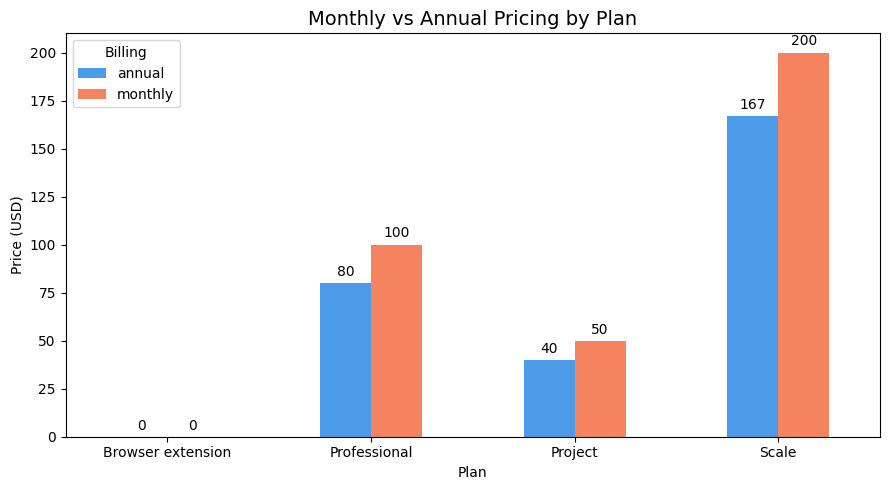

In [69]:
# ===============================
# ANALYTICS & VISUALIZATIONS
# ===============================

# only plans with numeric pricing
df_plot = df.dropna(subset=["price_numeric"])

pivot = df_plot.pivot(index="plan_name", columns="billing", values="price_numeric")

# --- Graph ---
ax = pivot.plot(kind="bar", figsize=(9, 5), color=["#4C9BE8", "#F4845F"])

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Monthly vs Annual Pricing by Plan", fontsize=14)
plt.xlabel("Plan")
plt.ylabel("Price (USD)")
plt.xticks(rotation=0)
plt.legend(title="Billing")
plt.tight_layout()
plt.savefig("pricing_comparison.png", dpi=150)
plt.show()


In [70]:
# Savings
pivot["monthly_total_year"] = pivot["monthly"] * 12
pivot["annual_total_year"] = pivot["annual"] * 12
pivot["annual_savings_usd"] = pivot["monthly_total_year"] - pivot["annual_total_year"]
pivot["savings_pct"] = ( pivot["annual_savings_usd"] / pivot["monthly_total_year"] * 100 ).round(1)

print("\n📊 Analysis:")
print(pivot[["monthly_total_year", "annual_total_year", "annual_savings_usd", "savings_pct"]].to_string())





📊 Savings Analysis:
billing            monthly_total_year  annual_total_year  annual_savings_usd  savings_pct
plan_name                                                                                
Browser extension                 0.0                0.0                 0.0          NaN
Professional                   1200.0              960.0               240.0         20.0
Project                         600.0              480.0               120.0         20.0
Scale                          2400.0             2004.0               396.0         16.5


## Insights

- The discount percentage is consistent across plans (16.5% - 20%).
- Higher-tier plans generate larger absolute savings, but not higher relative savings.
- The pricing model is linear: doubling the plan roughly doubles the price.
- This suggests a simple, scalable pricing strategy rather than tiered value-based pricing.

## Conclusion

The company uses a predictable pricing structure with consistent discounts for annual subscriptions.
This encourages long-term commitment while keeping pricing transparent.